# 1.0 Obtain a dataset and frame the predictive problem

 ### 1.1 Introduction

This project aims to predict house prices in King County, USA, using transaction data from 2014–2015. The problem is treated as a supervised regression task with price as the target variable. Initial exploration showed that prices are highly right-skewed, so a log transformation was applied to reduce variance and improve model stability. Several models, including linear regression and tree-based methods, are compared to evaluate predictive performance and generalisation. Agent tools were used to assist with coding and debugging, but all modelling decisions and evaluation steps were manually checked to ensure correctness.


### 1.2 Data Loading

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [83]:
df = pd.read_csv("kc_house_data.csv")

print(df.shape)
print(df.columns)
df.head()

(21613, 21)
Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### 1.3 Define target and prediction type

In [84]:
# Define target (raw)
target = "price"

print("Prediction type: Regression")
print("Primary metric: RMSE")

Prediction type: Regression
Primary metric: RMSE


# 2.0 EDA

### 2.1 Data Overview and Initial Inspection


In [85]:
df.info()
df.isna().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [86]:
#  Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

# Duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

#  Target sanity check
print("Min price:", df["price"].min())
print("Any non-positive prices?", (df["price"] <= 0).any())



Missing values per column:
Series([], dtype: int64)
Number of duplicate rows: 0
Min price: 75000.0
Any non-positive prices? False


### 2.2 Data visualisation

#### 2.2.1 Distribution of House Price (Raw Scale)

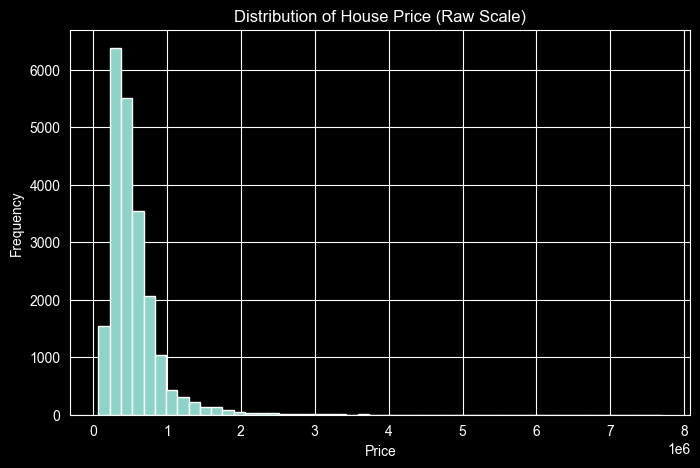

In [87]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=50)
plt.title("Distribution of House Price (Raw Scale)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

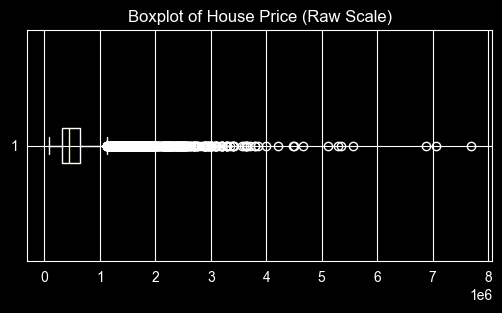

In [88]:
plt.figure(figsize=(6,3))
plt.boxplot(df["price"], vert=False)
plt.title("Boxplot of House Price (Raw Scale)")
plt.show()

#### 2.2.2 Distribution of House Price After Log Transformation

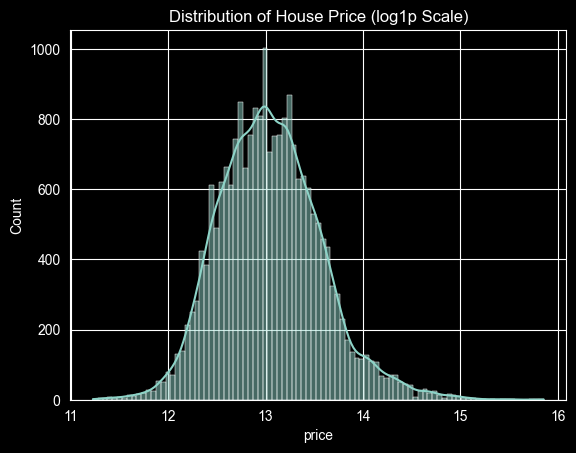

In [89]:
sns.histplot(np.log1p(df["price"]), kde=True)
plt.title("Distribution of House Price (log1p Scale)")
plt.show()

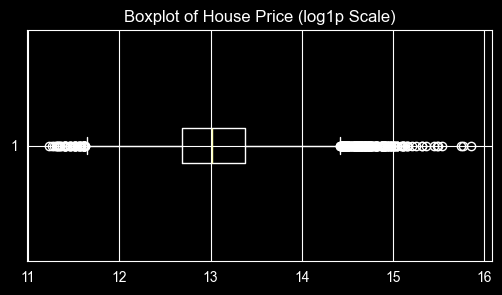

In [90]:
plt.figure(figsize=(6,3))
plt.boxplot(np.log1p(df["price"]), vert=False)
plt.title("Boxplot of House Price (log1p Scale)")
plt.show()

#### 2.2.3 Relationship Between House Price and Living Area

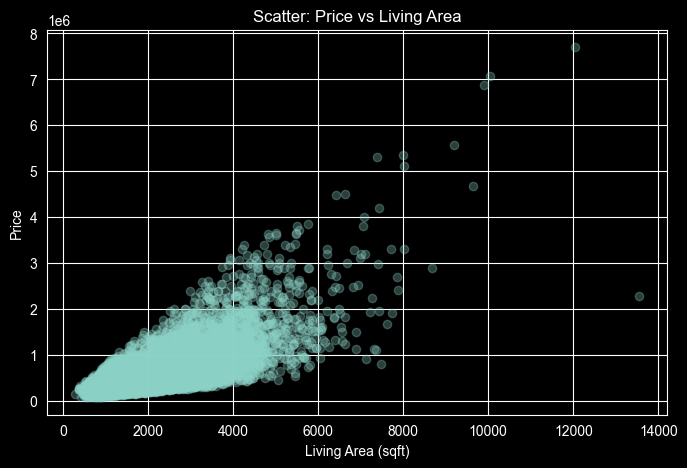

In [91]:
plt.figure(figsize=(8,5))
plt.scatter(df["sqft_living"], df["price"], alpha=0.3)
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.title("Scatter: Price vs Living Area")
plt.show()

#### 2.2.4 Correlation Between Features and Log House Price

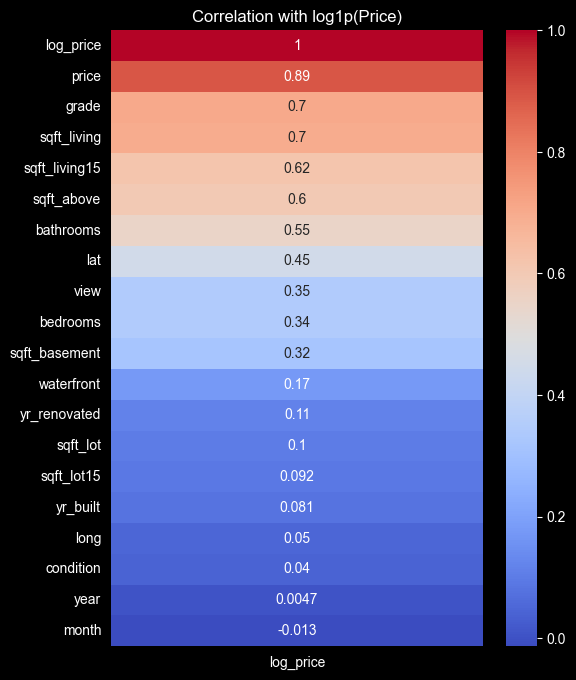

In [108]:
df_tmp = df.copy()
df_tmp["log_price"] = np.log1p(df_tmp["price"])

corr = df_tmp.corr(numeric_only=True)
log_corr = corr[["log_price"]].sort_values(by="log_price", ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(log_corr, annot=True, cmap="coolwarm")
plt.title("Correlation with log1p(Price)")
plt.show()


# 3.0 Data Preparation

### 3.1 Initial Cleaning

In [94]:
# Remove unique identifier column as it does not contain predictive information
# and would not generalise to new unseen observations
df = df.drop(columns=["id"])

### 3.2 Temporal Feature Engineering

In [95]:
# Convert date column to datetime format to enable temporal feature extraction
df["date"] = pd.to_datetime(df["date"])

# Extract year of transaction to capture potential time trends in housing prices
df["year"] = df["date"].dt.year

# Extract month of transaction to capture potential seasonal effects
df["month"] = df["date"].dt.month

# Remove original date column to avoid redundancy and prevent models from using raw timestamp values
df = df.drop(columns=["date"])

In [96]:
# Verify that temporal features were extracted correctly from the original date variable
print(df[["year", "month"]].head(10))

   year  month
0  2014     10
1  2014     12
2  2015      2
3  2014     12
4  2015      2
5  2014      5
6  2014      6
7  2015      1
8  2015      4
9  2015      3


### 3.3 Feature Type Correction

In [97]:
# Convert zipcode to categorical type as it represents location categories rather than numeric magnitude
df["zipcode"] = df["zipcode"].astype("category")

# Convert floors to categorical type since it represents discrete structural categories
df["floors"] = df["floors"].astype("category")

### 3.4 Verification of Data Types

In [98]:
# Verify that all feature types are correctly assigned before modelling
print(df.dtypes)

price             float64
bedrooms            int64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors           category
waterfront          int64
view                int64
condition           int64
grade               int64
sqft_above          int64
sqft_basement       int64
yr_built            int64
yr_renovated        int64
zipcode          category
lat               float64
long              float64
sqft_living15       int64
sqft_lot15          int64
year                int32
month               int32
dtype: object


### 3.5 Train/Test Split

In [99]:
# Target and features
y = np.log1p(df["price"])
X = df.drop(columns=["price", "log_price"], errors="ignore")

# Stratified split based on price bins
bins = pd.qcut(df["price"], q=10, duplicates="drop")

# Split dataset into training and testing sets to evaluate model generalisation performance
# Stratification ensures similar price distribution across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=bins
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (17290, 20)
Test shape: (4323, 20)


### 3.6 Preprocessing Pipeline

In [100]:
# Preprocessing
cat_cols = []
for c in ["zipcode", "floors"]:
    if c in X.columns:
        cat_cols.append(c)

num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)


# 4.0 Modelling

### 4.1 Evaluation metric (RMSE)

In [109]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

### 4.2 Baseline (DummyRegressor)

In [102]:
dummy_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)

dummy_rmse = rmse(y_test, dummy_pred)
print(f"Dummy RMSE (log scale): {dummy_rmse:.4f}")

Dummy RMSE (log scale): 0.5292


### 4.3 Linear Regression

In [103]:
lin_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

lin_rmse = rmse(y_test, lin_pred)
print(f"Linear Regression RMSE (log scale): {lin_rmse:.4f}")

Linear Regression RMSE (log scale): 0.2203


### 4.4 Decision Tree

In [104]:
dt_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print(f"Decision Tree RMSE (log scale): {rmse(y_test, dt_pred):.4f}")


Decision Tree RMSE (log scale): 0.2458


### 4.5 Random Forest

In [105]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = rmse(y_test, rf_pred)
print(f"Random Forest RMSE (log scale): {rf_rmse:.4f}")


Random Forest RMSE (log scale): 0.1717


### 4.6 XGBoost

In [110]:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror",
        tree_method="hist"
    ))
])

xgb_pipe.fit(X_train, y_train)
xgb_pred = xgb_pipe.predict(X_test)

xgb_rmse = rmse(y_test, xgb_pred)
print(f"XGBoost RMSE (log scale): {xgb_rmse:.4f}")

XGBoost RMSE (log scale): 0.1528


In [111]:
results = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE (log scale)": [
        dummy_rmse,
        lin_rmse,
        rmse(y_test, dt_pred),
        rf_rmse,
        xgb_rmse
    ]
})

results.sort_values("RMSE (log scale)")

,Model,RMSE (log scale)
4,XGBoost,0.152796
3,Random Forest,0.171710
1,Linear Regression,0.220317
2,Decision Tree,0.245776
0,Dummy Regressor,0.529204


In [112]:
best_model = xgb_pipe
print("Best model selected: XGBoost")

Best model selected: XGBoost


# 5.0 Fine-tune and evaluate

### 5.1 Hyperparameter search

In [127]:
for depth in [3, 5,6, 7, 9]:
    xgb_pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=depth,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror",
            tree_method="hist"
        ))
    ])

    cv_scores = -cross_val_score(
        xgb_pipe, X_train, y_train,
        scoring="neg_root_mean_squared_error",
        cv=5
    )

    print(f"max_depth {depth} -> CV RMSE: {cv_scores.mean():.4f}")

max_depth 3 -> CV RMSE: 0.1680
max_depth 5 -> CV RMSE: 0.1614
max_depth 6 -> CV RMSE: 0.1604
max_depth 7 -> CV RMSE: 0.1609
max_depth 9 -> CV RMSE: 0.1636


### 5.2 Cross-validation

In [128]:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror",
        tree_method="hist"
    ))
])

cv_rmse = -cross_val_score(
    xgb_pipe, X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
).mean()

print(f"XGBoost 5-fold CV RMSE (log scale): {cv_rmse:.4f}")


XGBoost 5-fold CV RMSE (log scale): 0.1604


### 5.3 Back-transform to price scale (interpretation)

In [130]:
y_test_price = np.expm1(y_test)
xgb_pred_price = np.expm1(xgb_pred)

xgb_rmse_price = np.sqrt(mean_squared_error(y_test_price, xgb_pred_price))
print(f"XGBoost RMSE (price scale): {xgb_rmse_price:,.0f}")

XGBoost RMSE (price scale): 104,794


### 5.4 Overfitting check (train vs test RMSE)

In [131]:
# Fit pipeline FIRST
xgb_pipe.fit(X_train, y_train)

# Train prediction
xgb_train_pred = xgb_pipe.predict(X_train)
xgb_train_rmse = rmse(y_train, xgb_train_pred)

# Test prediction (you already computed earlier, but safe to recompute)
xgb_test_pred = xgb_pipe.predict(X_test)
xgb_test_rmse = rmse(y_test, xgb_test_pred)

print("Train RMSE:", xgb_train_rmse)
print("Test RMSE:", xgb_test_rmse)

Train RMSE: 0.11071534890513067
Test RMSE: 0.15279619402409578


### 5.5 Feature importance

In [132]:
# Get fitted preprocessing from pipeline
pre = xgb_pipe.named_steps["preprocess"]

# Get feature names after one-hot encoding
feature_names = pre.get_feature_names_out()

# Get XGBoost model from pipeline
xgb_model = xgb_pipe.named_steps["model"]

# Get feature importance
importances = xgb_model.feature_importances_

# Create pandas Series
feature_importances = pd.Series(
    importances,
    index=feature_names
).sort_values(ascending=False)

# Show top 10
print(feature_importances.head(10))


num__grade            0.278200
num__lat              0.101482
num__sqft_living      0.092982
cat__zipcode_98023    0.053274
cat__zipcode_98004    0.038458
num__waterfront       0.031014
num__view             0.024496
cat__zipcode_98112    0.016550
num__long             0.014784
num__sqft_living15    0.014071
dtype: float32


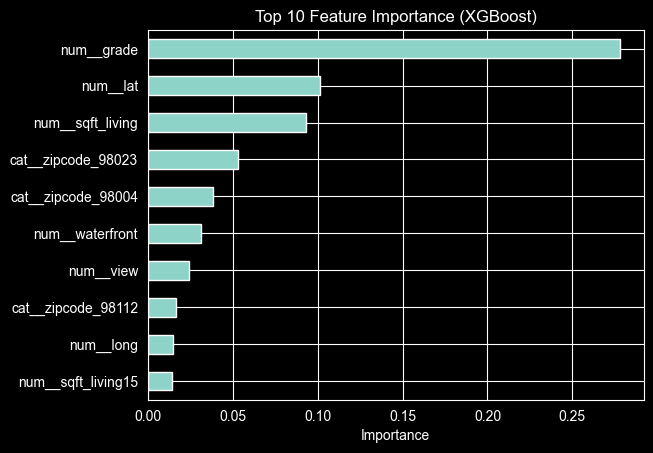

In [133]:
# Plot top 10 feature importance

top10 = feature_importances.head(10)

plt.figure()
top10.sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

 ### 5.6 Residual analysis

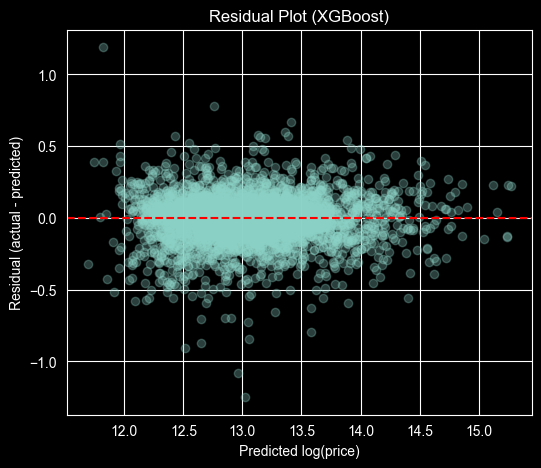

In [134]:
# Predictions on log scale (already exists, but recompute for safety)
xgb_test_pred = xgb_pipe.predict(X_test)

# Residuals on log scale
residuals = y_test - xgb_test_pred

# Plot residuals vs predicted values
plt.figure(figsize=(6,5))
plt.scatter(xgb_test_pred, residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted log(price)")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual Plot (XGBoost)")
plt.show()

### 5.7 Actual vs Predicted (price scale)

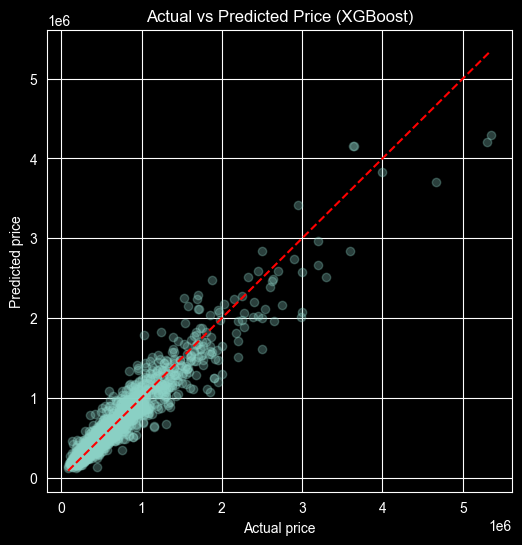

In [135]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_price, xgb_pred_price, alpha=0.3)

# perfect prediction line
min_val = min(y_test_price.min(), xgb_pred_price.min())
max_val = max(y_test_price.max(), xgb_pred_price.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted Price (XGBoost)")
plt.show()

# 6.0 Final Model and Conclusion

### 6.1 Final Model Choice

Among all models tested, XGBoost achieved the lowest test RMSE and demonstrated strong and consistent performance during cross-validation. Compared with Linear Regression and Random Forest, XGBoost better captures nonlinear relationships and interactions between features, resulting in improved predictive accuracy.

Therefore, XGBoost is selected as the final model due to its superior generalisation performance and robustness.

### 6.2 Final Performance Summary

In [136]:
print("Final Model: XGBoost")
print(f"Test RMSE (log scale): {xgb_rmse:.4f}")
print(f"CV RMSE (log scale): {cv_rmse:.4f}")

# Back-transform to price scale
y_test_price = np.expm1(y_test)
xgb_pred_price = np.expm1(xgb_pipe.predict(X_test))

rmse_price = np.sqrt(mean_squared_error(y_test_price, xgb_pred_price))

print(f"RMSE (price scale): {rmse_price:,.0f}")

Final Model: XGBoost
Test RMSE (log scale): 0.1528
CV RMSE (log scale): 0.1604
RMSE (price scale): 104,794
